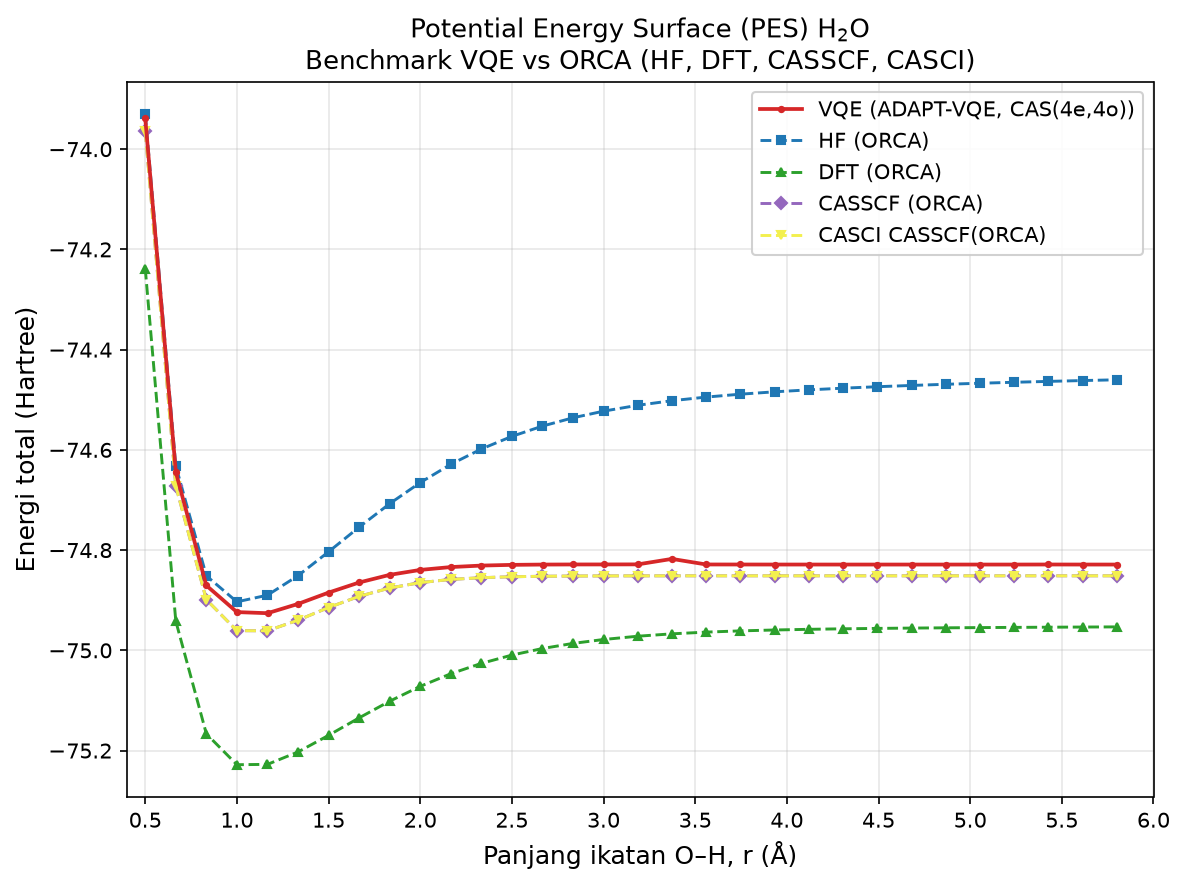

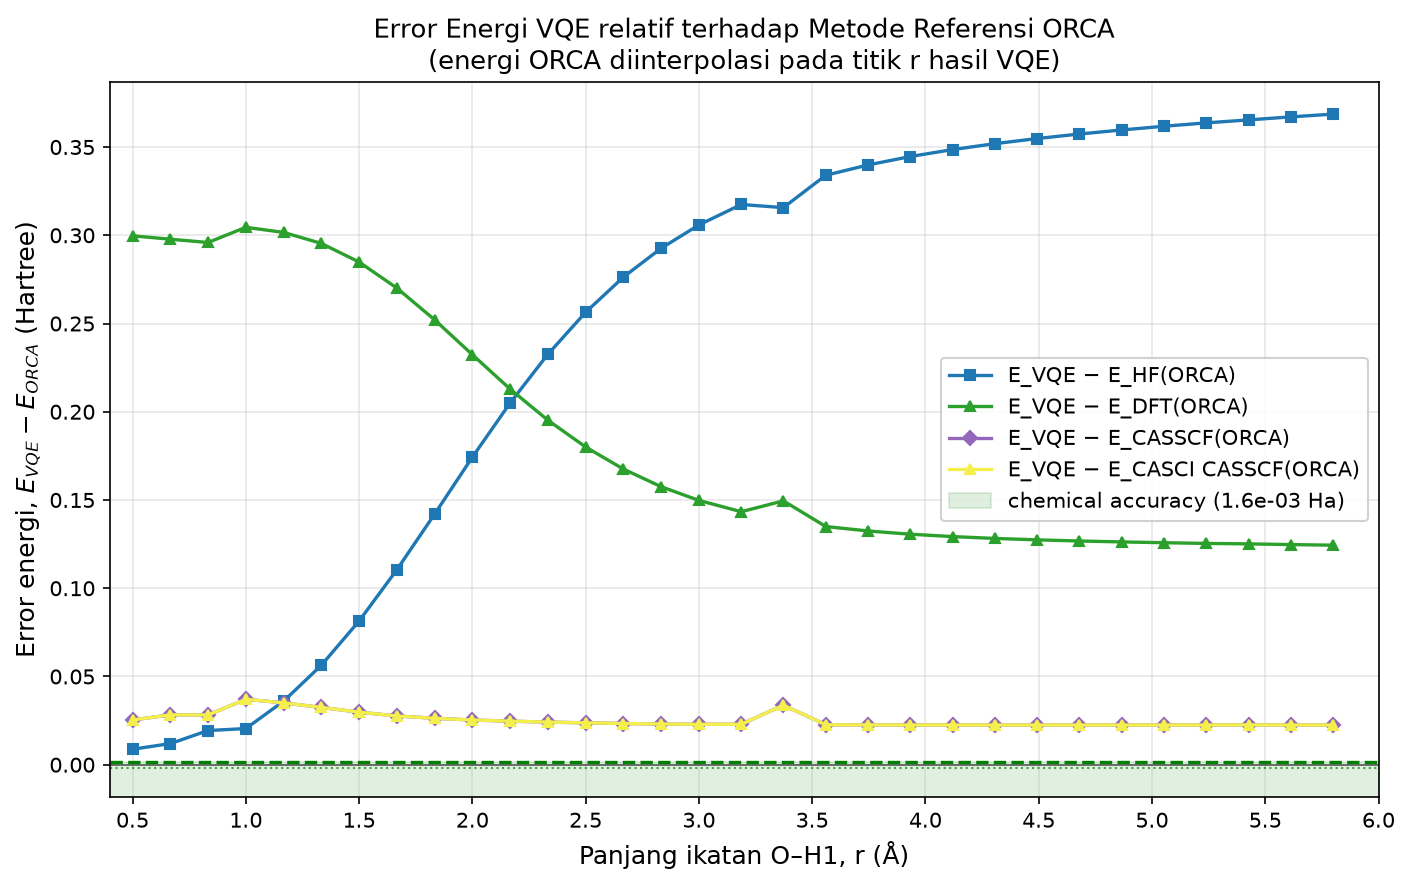

  r(Å)          ΔHF         ΔDFT      ΔCASSCF ΔCASCI CASSCF
  0.50   8.7628e-03   2.9969e-01   2.5362e-02   2.5362e-02
  0.67   1.1976e-02   2.9777e-01   2.8241e-02   2.8241e-02
  0.83   1.9363e-02   2.9590e-01   2.8208e-02   2.8208e-02
  1.00   2.0483e-02   3.0452e-01   3.7067e-02   3.7067e-02
  1.17   3.6045e-02   3.0161e-01   3.5039e-02   3.5039e-02
  1.33   5.6318e-02   2.9540e-01   3.2459e-02   3.2459e-02
  1.50   8.1449e-02   2.8484e-01   2.9769e-02   2.9769e-02
  1.67   1.1054e-01   2.7006e-01   2.7619e-02   2.7619e-02
  1.83   1.4195e-01   2.5214e-01   2.6299e-02   2.6299e-02
  2.00   1.7428e-01   2.3233e-01   2.5344e-02   2.5344e-02
  2.17   2.0504e-01   2.1283e-01   2.4670e-02   2.4670e-02
  2.33   2.3252e-01   1.9524e-01   2.4155e-02   2.4155e-02
  2.50   2.5638e-01   1.8003e-01   2.3711e-02   2.3711e-02
  2.67   2.7634e-01   1.6750e-01   2.3351e-02   2.3351e-02
  2.83   2.9261e-01   1.5755e-01   2.3076e-02   2.3076e-02
  3.00   3.0585e-01   1.4976e-01   2.2880e-02   2.2880e

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

OUT_DIR = "/mnt/user-data/outputs"

# ----------------------------------------------------------------------
# 1. DATA (hasil ekstraksi dari file .out)
# ----------------------------------------------------------------------
data_evqe = [
    {"r": 0.500, "vqe": -73.93878087, "fci": -73.93968152, "err": 9.01e-04},
    {"r": 0.667, "vqe": -74.64475938, "fci": -74.64603533, "err": 1.28e-03},
    {"r": 0.833, "vqe": -74.87047382, "fci": -74.87050932, "err": 3.55e-05},
    {"r": 1.000, "vqe": -74.92368085, "fci": -74.92371855, "err": 3.77e-05},
    {"r": 1.167, "vqe": -74.92587753, "fci": -74.92598511, "err": 1.08e-04},
    {"r": 1.333, "vqe": -74.90741034, "fci": -74.90764361, "err": 2.33e-04},
    {"r": 1.500, "vqe": -74.88477343, "fci": -74.88491777, "err": 1.44e-04},
    {"r": 1.667, "vqe": -74.86459218, "fci": -74.86460097, "err": 8.79e-06},
    {"r": 1.833, "vqe": -74.84938024, "fci": -74.84938211, "err": 1.88e-06},
    {"r": 2.000, "vqe": -74.83950834, "fci": -74.83950914, "err": 7.97e-07},
    {"r": 2.167, "vqe": -74.83382183, "fci": -74.83382218, "err": 3.43e-07},
    {"r": 2.333, "vqe": -74.83084984, "fci": -74.83085000, "err": 1.57e-07},
    {"r": 2.500, "vqe": -74.82943332, "fci": -74.82943340, "err": 7.68e-08},
    {"r": 2.667, "vqe": -74.82883356, "fci": -74.82883360, "err": 4.03e-08},
    {"r": 2.833, "vqe": -74.82862888, "fci": -74.82862891, "err": 2.82e-08},
    {"r": 3.000, "vqe": -74.82858894, "fci": -74.82858897, "err": 2.12e-08},
    {"r": 3.187, "vqe": -74.82845162, "fci": -74.82869834, "err": 2.47e-04},
    {"r": 3.373, "vqe": -74.81754750, "fci": -74.81810758, "err": 5.60e-04},
    {"r": 3.560, "vqe": -74.82865027, "fci": -74.82874528, "err": 9.50e-05},
    {"r": 3.747, "vqe": -74.82870699, "fci": -74.82875620, "err": 4.92e-05},
    {"r": 3.933, "vqe": -74.82876932, "fci": -74.82878803, "err": 1.87e-05},
    {"r": 4.120, "vqe": -74.82878038, "fci": -74.82878733, "err": 6.95e-06},
    {"r": 4.307, "vqe": -74.82879575, "fci": -74.82880045, "err": 4.70e-06},
    {"r": 4.493, "vqe": -74.82879954, "fci": -74.82880125, "err": 1.72e-06},
    {"r": 4.680, "vqe": -74.82880078, "fci": -74.82880145, "err": 6.66e-07},
    {"r": 4.867, "vqe": -74.82879326, "fci": -74.82879341, "err": 1.54e-07},
    {"r": 5.053, "vqe": -74.82880112, "fci": -74.82880121, "err": 9.84e-08},
    {"r": 5.240, "vqe": -74.82880151, "fci": -74.82880158, "err": 6.08e-08},
    {"r": 5.427, "vqe": -74.82870212, "fci": -74.82870218, "err": 6.57e-08},
    {"r": 5.613, "vqe": -74.82877603, "fci": -74.82877603, "err": 1.27e-09},
    {"r": 5.800, "vqe": -74.82880162, "fci": -74.82880168, "err": 5.97e-08},
]

# ORCA HF: r (Å), E_HF (Ha)
data_hf = [
    {"r": 0.50000, "hf": -73.93001802},
    {"r": 0.66667, "hf": -74.63199357},
    {"r": 0.83333, "hf": -74.85131023},
    {"r": 1.00000, "hf": -74.90319818},
    {"r": 1.16667, "hf": -74.88989393},
    {"r": 1.33333, "hf": -74.85100345},
    {"r": 1.50000, "hf": -74.80332420},
    {"r": 1.66667, "hf": -74.75414603},
    {"r": 1.83333, "hf": -74.70734609},
    {"r": 2.00000, "hf": -74.66523199},
    {"r": 2.16667, "hf": -74.62884602},
    {"r": 2.33333, "hf": -74.59827037},
    {"r": 2.50000, "hf": -74.57305376},
    {"r": 2.66667, "hf": -74.55253183},
    {"r": 2.83333, "hf": -74.53599184},
    {"r": 3.00000, "hf": -74.52274133},
    {"r": 3.18667, "hf": -74.51102562},
    {"r": 3.37333, "hf": -74.50187094},
    {"r": 3.56000, "hf": -74.49464791},
    {"r": 3.74667, "hf": -74.48886055},
    {"r": 3.93333, "hf": -74.48414621},
    {"r": 4.12000, "hf": -74.48022420},
    {"r": 4.30667, "hf": -74.47688401},
    {"r": 4.49333, "hf": -74.47398705},
    {"r": 4.68000, "hf": -74.47142294},
    {"r": 4.86667, "hf": -74.46912238},
    {"r": 5.05333, "hf": -74.46702894},
    {"r": 5.24000, "hf": -74.46510857},
    {"r": 5.42667, "hf": -74.46333378},
    {"r": 5.61333, "hf": -74.46168474},
    {"r": 5.80000, "hf": -74.46014629},
]

# ORCA DFT (B3LYP): r (Å), E_DFT (Ha)
data_dft = [
    {"r": 0.50000, "dft": -74.23847031},
    {"r": 0.66667, "dft": -74.94173266},
    {"r": 0.83333, "dft": -75.16659376},
    {"r": 1.00000, "dft": -75.22820209},
    {"r": 1.16667, "dft": -75.22752592},
    {"r": 1.33333, "dft": -75.20274826},
    {"r": 1.50000, "dft": -75.16961216},
    {"r": 1.66667, "dft": -75.13471569},
    {"r": 1.83333, "dft": -75.10146147},
    {"r": 2.00000, "dft": -75.07183696},
    {"r": 2.16667, "dft": -75.04669939},
    {"r": 2.33333, "dft": -75.02604858},
    {"r": 2.50000, "dft": -75.00946034},
    {"r": 2.66667, "dft": -74.99635454},
    {"r": 2.83333, "dft": -74.98616127},
    {"r": 3.00000, "dft": -74.97834902},
    {"r": 3.18667, "dft": -74.97181159},
    {"r": 3.37333, "dft": -74.96705275},
    {"r": 3.56000, "dft": -74.96361851},
    {"r": 3.74667, "dft": -74.96115544},
    {"r": 3.93333, "dft": -74.95937577},
    {"r": 4.12000, "dft": -74.95804457},
    {"r": 4.30667, "dft": -74.95701642},
    {"r": 4.49333, "dft": -74.95620992},
    {"r": 4.68000, "dft": -74.95556611},
    {"r": 4.86667, "dft": -74.95503800},
    {"r": 5.05333, "dft": -74.95459010},
    {"r": 5.24000, "dft": -74.95419424},
    {"r": 5.42667, "dft": -74.95383412},
    {"r": 5.61333, "dft": -74.95350193},
    {"r": 5.80000, "dft": -74.95319312},
]

# ORCA CASSCF (SlowConv, CAS(4,4)): r (Å), E_CASSCF (Ha)
data_casscf = [
    {"r": 0.50000, "casscf": -73.96414241},
    {"r": 0.66667, "casscf": -74.67219796},
    {"r": 0.83333, "casscf": -74.89889803},
    {"r": 1.00000, "casscf": -74.96074808},
    {"r": 1.16667, "casscf": -74.96094708},
    {"r": 1.33333, "casscf": -74.93981974},
    {"r": 1.50000, "casscf": -74.91454271},
    {"r": 1.66667, "casscf": -74.89224958},
    {"r": 1.83333, "casscf": -74.87565238},
    {"r": 2.00000, "casscf": -74.86485232},
    {"r": 2.16667, "casscf": -74.85850073},
    {"r": 2.33333, "casscf": -74.85500007},
    {"r": 2.50000, "casscf": -74.85314410},
    {"r": 2.66667, "casscf": -74.85218636},
    {"r": 2.83333, "casscf": -74.85170469},
    {"r": 3.00000, "casscf": -74.85146908},
    {"r": 3.18667, "casscf": -74.85134857},
    {"r": 3.37333, "casscf": -74.85129807},
    {"r": 3.56000, "casscf": -74.85127774},
    {"r": 3.74667, "casscf": -74.85126990},
    {"r": 3.93333, "casscf": -74.85126698},
    {"r": 4.12000, "casscf": -74.85126594},
    {"r": 4.30667, "casscf": -74.85126559},
    {"r": 4.49333, "casscf": -74.85126549},
    {"r": 4.68000, "casscf": -74.85126546},
    {"r": 4.86667, "casscf": -74.85126546},
    {"r": 5.05333, "casscf": -74.85126546},
    {"r": 5.24000, "casscf": -74.85126546},
    {"r": 5.42667, "casscf": -74.85126546},
    {"r": 5.61333, "casscf": -74.85126546},
    {"r": 5.80000, "casscf": -74.85126546},
]

# ORCA CASCI 1 (CAS(4,4), orbital HF): r (Å), E_CASCI (Ha)
data_ecasci_hf=[
    {"r": 0.50000, "casci_hf": -71.28586047},
    {"r": 0.66667, "casci_hf": -72.54547768},
    {"r": 0.83333, "casci_hf": -73.24784602},
    {"r": 1.00000, "casci_hf": -73.65896301},
    {"r": 1.16667, "casci_hf": -73.90385681},
    {"r": 1.33333, "casci_hf": -74.04895259},
    {"r": 1.50000, "casci_hf": -74.13404953},
    {"r": 1.66667, "casci_hf": -74.18292342},
    {"r": 1.83333, "casci_hf": -74.20940012},
    {"r": 2.00000, "casci_hf": -74.22178063},
    {"r": 2.16667, "casci_hf": -74.22531318},
    {"r": 2.33333, "casci_hf": -74.22340876},
    {"r": 2.50000, "casci_hf": -74.21829782},
    {"r": 2.66667, "casci_hf": -74.21143224},
    {"r": 2.83333, "casci_hf": -74.20374398},
    {"r": 3.00000, "casci_hf": -74.19581603},
]

# ORCA CASCI 2 (CAS(2,2), orbital CASSCF): r (Å), E_CASCI (Ha)
data_ecasci_casscf = [
    {"r": 0.50000, "casci_casscf": -73.96414241},
    {"r": 0.66667, "casci_casscf": -74.67219796},
    {"r": 0.83333, "casci_casscf": -74.89889803},
    {"r": 1.00000, "casci_casscf": -74.96074808},
    {"r": 1.16667, "casci_casscf": -74.96094708},
    {"r": 1.33333, "casci_casscf": -74.93981974},
    {"r": 1.50000, "casci_casscf": -74.91454271},
    {"r": 1.66667, "casci_casscf": -74.89224958},
    {"r": 1.83333, "casci_casscf": -74.87565238},
    {"r": 2.00000, "casci_casscf": -74.86485232},
    {"r": 2.16667, "casci_casscf": -74.85850073},
    {"r": 2.33333, "casci_casscf": -74.85500007},
    {"r": 2.50000, "casci_casscf": -74.85314410},
    {"r": 2.66667, "casci_casscf": -74.85218636},
    {"r": 2.83333, "casci_casscf": -74.85170469},
    {"r": 3.00000, "casci_casscf": -74.85146908},
    {"r": 3.18667, "casci_casscf": -74.85134855},
    {"r": 3.37333, "casci_casscf": -74.85129808},
    {"r": 3.56000, "casci_casscf": -74.85127774},
    {"r": 3.74667, "casci_casscf": -74.85126990},
    {"r": 3.93333, "casci_casscf": -74.85126698},
    {"r": 4.12000, "casci_casscf": -74.85126594},
    {"r": 4.30667, "casci_casscf": -74.85126559},
    {"r": 4.49333, "casci_casscf": -74.85126549},
    {"r": 4.68000, "casci_casscf": -74.85126546},
    {"r": 4.86667, "casci_casscf": -74.85126546},
    {"r": 5.05333, "casci_casscf": -74.85126546},
    {"r": 5.24000, "casci_casscf": -74.85126546},
    {"r": 5.42667, "casci_casscf": -74.85126546},
    {"r": 5.61333, "casci_casscf": -74.85126546},
    {"r": 5.80000, "casci_casscf": -74.85126546},
]

# ----------------------------------------------------------------------
# 2. KONVERSI KE ARRAY NUMPY
# ----------------------------------------------------------------------
r_vqe = np.array([d["r"] for d in data_evqe])
e_vqe = np.array([d["vqe"] for d in data_evqe])

r_hf = np.array([d["r"] for d in data_hf]);         e_hf_orca = np.array([d["hf"] for d in data_hf])
r_dft = np.array([d["r"] for d in data_dft]);       e_dft_orca = np.array([d["dft"] for d in data_dft])
r_casscf = np.array([d["r"] for d in data_casscf]); e_casscf_orca = np.array([d["casscf"] for d in data_casscf])
r_casci_hf = np.array([d["r"] for d in data_ecasci_hf]);   e_casci_hf_orca = np.array([d["casci_hf"] for d in data_ecasci_hf])
r_casci_casscf = np.array([d["r"] for d in data_ecasci_casscf]);   e_casci_casscf_orca = np.array([d["casci_casscf"] for d in data_ecasci_casscf])

# ----------------------------------------------------------------------
# 3. PLOT PES (semua metode pada sumbu r masing-masing)
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

ax.plot(r_vqe, e_vqe, marker=".", ms=5, lw=1.8, color="#d62728",
         label="VQE (ADAPT-VQE, CAS(4e,4o))", zorder=5)
ax.plot(r_hf, e_hf_orca, marker="s", ms=4, lw=1.4, ls="--", color="#1f77b4",
         label="HF (ORCA)")
ax.plot(r_dft, e_dft_orca, marker="^", ms=4, lw=1.4, ls="--", color="#2ca02c",
         label="DFT (ORCA)")
ax.plot(r_casscf, e_casscf_orca, marker="D", ms=4, lw=1.4, ls="--", color="#9467bd",
         label="CASSCF (ORCA)")
#ax.plot(r_casci_hf, e_casci_hf_orca, marker="v", ms=4, lw=1.4, ls="--", color="#ff7f0e",
#         label="CASCI HF(ORCA)")
ax.plot(r_casci_casscf, e_casci_casscf_orca, marker="v", ms=4, lw=1.4, ls="--", color="#F3F04E",
         label="CASCI CASSCF(ORCA)")

ax.set_xlabel("Panjang ikatan O–H, r (Å)", fontsize=12)
ax.set_ylabel("Energi total (Hartree)", fontsize=12)
ax.set_title("Potential Energy Surface (PES) H$_2$O\nBenchmark VQE vs ORCA (HF, DFT, CASSCF, CASCI)",
              fontsize=12.5)
ax.set_xticks([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0])
ax.set_xlim(0.4, 6.0)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc="upper right", framealpha=0.9)
fig.tight_layout()
#fig.savefig(f"{OUT_DIR}/H2O_PES_benchmark.png", dpi=300)
plt.show(fig)

# ----------------------------------------------------------------------
# 4. PLOT ERROR (E_VQE - E_ORCA), diinterpolasi pada titik r VQE
#    + garis batas chemical accuracy (±1.6e-3 Ha)
# ----------------------------------------------------------------------
CHEM_ACC = 1.6e-3  # Hartree (~1 kcal/mol)

def interp_to_vqe_grid(r_ref, e_ref, r_target):
    cs = CubicSpline(r_ref, e_ref)
    return cs(r_target)
 
e_hf_on_vqe = interp_to_vqe_grid(r_hf, e_hf_orca, r_vqe)
e_dft_on_vqe = interp_to_vqe_grid(r_dft, e_dft_orca, r_vqe)
e_casscf_on_vqe = interp_to_vqe_grid(r_casscf, e_casscf_orca, r_vqe)
e_casci_hf_on_vqe = interp_to_vqe_grid(r_casci_hf, e_casci_hf_orca, r_vqe)
e_casci_casscf_on_vqe = interp_to_vqe_grid(r_casci_casscf, e_casci_casscf_orca, r_vqe)
 
err_hf = abs(e_vqe - e_hf_on_vqe)
err_dft = abs(e_vqe - e_dft_on_vqe)
err_casscf = abs(e_vqe - e_casscf_on_vqe)
err_casci_hf = abs(e_vqe - e_casci_hf_on_vqe)
err_casci_casscf = abs(e_vqe - e_casci_casscf_on_vqe)
 
fig2, ax2 = plt.subplots(figsize=(9.5, 6), dpi=150)
 
# Rentang y plot, biar arsiran chem. acc. pas menutupi seluruh lebar bawah
y_bottom, y_top = ax2.get_ylim()  # placeholder, akan di-set ulang setelah plot
 
ax2.axhline(0, color="black", lw=0.8, alpha=0.6)
 
ax2.plot(r_vqe, err_hf, marker="s", ms=5, lw=1.6, color="#1f77b4",
          label="E_VQE − E_HF(ORCA)")
ax2.plot(r_vqe, err_dft, marker="^", ms=5, lw=1.6, color="#2ca02c",
          label="E_VQE − E_DFT(ORCA)")
ax2.plot(r_vqe, err_casscf, marker="D", ms=5, lw=1.6, color="#9467bd",
          label="E_VQE − E_CASSCF(ORCA)")
#ax2.plot(r_vqe, err_casci_hf, marker="v", ms=5, lw=1.6, color="#ff7f0e",
#          label="E_VQE − E_CASCI HF(ORCA)")
ax2.plot(r_vqe, err_casci_casscf, marker="^", ms=5, lw=1.6, color="#F3F04E",
          label="E_VQE − E_CASCI CASSCF(ORCA)")
 
# Tentukan batas y berdasarkan data yang sudah diplot
y_min_data = min(err_hf.min(), err_dft.min(), err_casci_hf.min(), err_casci_casscf.min())
y_max_data = max(err_hf.max(), err_dft.max(), err_casci_hf.max(), err_casci_casscf.max())
margin = 0.08 * (y_max_data - y_min_data if y_max_data != y_min_data else 1.0)
y_bottom = y_min_data - margin
y_top = y_max_data + margin
ax2.set_ylim()
 
# Arsiran hijau: area DI BAWAH garis +CHEM_ACC (mencakup seluruh pita ±CHEM_ACC
# yang berada dalam rentang y plot, sampai batas bawah axes)
ax2.axhspan(y_bottom, CHEM_ACC, color="green", alpha=0.12, zorder=0,
             label=f"chemical accuracy ({CHEM_ACC:.1e} Ha)")
ax2.axhline(CHEM_ACC, color="green", lw=1.6, ls="--")
ax2.axhline(-CHEM_ACC, color="green", lw=1.0, ls=":", alpha=0.7)
 
ax2.set_xlabel("Panjang ikatan O–H1, r (Å)", fontsize=12)
ax2.set_ylabel("Error energi, $E_{VQE} - E_{ORCA}$ (Hartree)", fontsize=12)
ax2.set_title("Error Energi VQE relatif terhadap Metode Referensi ORCA\n"
               "(energi ORCA diinterpolasi pada titik r hasil VQE)", fontsize=12.5)
ax2.set_xticks([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0])
ax2.set_xlim(0.4, 6.0)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10, loc="best", framealpha=0.9)
fig2.tight_layout()
#fig2.savefig(f"{OUT_DIR}/H2O_PES_error.png", dpi=300)
plt.show(fig2)

print(f"{'r(Å)':>6} {'ΔHF':>12} {'ΔDFT':>12} {'ΔCASSCF':>12} {'ΔCASCI CASSCF':>12}")
for i in range(len(r_vqe)):
    print(f"{r_vqe[i]:6.2f} {err_hf[i]:12.4e} {err_dft[i]:12.4e} {err_casscf[i]:12.4e} {err_casci_casscf[i]:12.4e}")